# The Baseline


In [1]:
import numpy as np
import pandas as pd

from lib import plots
from lib.scores import max_expected_reward_guesses
from lib.utils import (
    cross_validate_model,
)

Goal: 
- Model the joint distribution of $X_h$ and $X_a$, representing the goals of the home and away team respectively
- Derive the prediction that maximizes the expected Kicktipp score under this distribution

Baseline Aproach:
- Use the empirical distribution of all matches to estimate the joint distribution of $X_h$ and $X_a$

In [2]:
class BaselineModel:
    """Simple baseline model using historical scoreline frequencies."""

    def __init__(self, max_goals=4):
        self.max_goals = max_goals

    def fit(self, df_matches):
        scorelines = df_matches[["home_goals", "away_goals"]].to_numpy()
        scorelines = np.clip(scorelines, 0, self.max_goals)
        counts = np.zeros((self.max_goals + 1, self.max_goals + 1), dtype=int)
        for hg, ag in scorelines:
            counts[hg, ag] += 1
        self.counts_ = counts
        self.probabilities_ = counts / np.sum(counts)

    def predict_proba(self, df_matches):
        n = df_matches.shape[0]
        probabilities = np.broadcast_to(
            self.probabilities_, (n,) + self.probabilities_.shape
        )
        return probabilities

    def predict(self, df_matches):
        probabilities = self.predict_proba(df_matches)
        guesses = max_expected_reward_guesses(probabilities, max_goals=self.max_goals)
        return guesses

In [3]:
# load data
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[(df_matches["season"] < 2025) & (df_matches["league"] == "bl1")]
df_train = df_matches[df_matches["season"] < 2024]
df_test = df_matches[df_matches["season"] == 2024]

In [4]:
model = BaselineModel()
model.fit(df_train)
probabilities = model.probabilities_

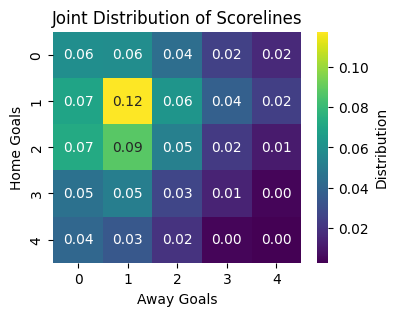

In [5]:
plots.join_distribution_heatmap(probabilities)

**Key insights**:
- 1:1 has the highest probability
- matrix is non-symmetric: home team has advantage
- high numbers of goals are rare

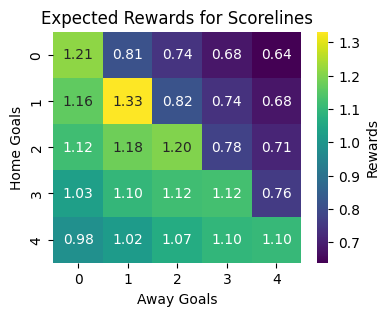

In [6]:
plots.expected_rewards_heatmap(probabilities)

**Key insight**: 1:1 gives highest expected reward -> Baseline model will always bet on 1:1

## Cross-validation

In [7]:
# Load data
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[(df_matches["season"] < 2025) & (df_matches["league"] == "bl1")]

In [8]:
cv_result = cross_validate_model(BaselineModel(max_goals=4), df_matches)
cv_result.print_summary()

Mean score: 409.6 ± 18.2
Individual scores: [406, 426, 382, 378, 404, 386, 414, 410, 430, 438, 408, 398, 426, 428]
